In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import types
import xarray as xr
import sys
import pandas as pd
from scipy.spatial.distance import cdist


sys.path.append("../..")

from src import IOFunctions
IO = IOFunctions.IO_Functions()

from src import Multicolour_Simulation_Functions
MSF = Multicolour_Simulation_Functions.MultiC_Sim_Funcs()

from src import sCMOSFunctions
sCMOS = sCMOSFunctions.sCMOS_Functions()

from src import SpectralFunctions
S_F = SpectralFunctions.Spectral_Funcs()

from src import MaskFunctions
M_F = MaskFunctions.Mask_Functions()

from src import PSFFunctions
PSF = PSFFunctions.PSF_Functions()

from src import PlottingFunctions

plotter = PlottingFunctions.Plotter(dark_background=True)

def euclidean_distance(ground_truth_points, fitted_points):
    """
    Calculates the minimum Euclidean distance from each fitted point to any ground truth point.

    This is appropriate for localization precision analysis where the number of
    fitted points may differ from the number of ground truth points.

    Args:
      ground_truth_points: A NumPy array of shape (n, 2) representing ground truth positions.
      fitted_points: A NumPy array of shape (m, 2) representing fitted positions.

    Returns:
      A NumPy array of shape (m,) containing the minimum distance from each fitted
      point to any ground truth point.
    """
    # Ensure both arrays are 2D
    ground_truth_points = np.atleast_2d(ground_truth_points)
    fitted_points = np.atleast_2d(fitted_points)

    # Calculate distance matrix and return minimum distance for each fitted point
    distance_matrix = np.linalg.norm(ground_truth_points - fitted_points, axis=1)
    return distance_matrix

INFO:Constants:Logging to file: /home/jbeckwith/Documents/pCloud/Chemistry/Lee/Code/Python/pyBayerSMLM/logs/Constants_20260226_140121.log
/tmp/ipykernel_1501682/2187897993.py:33: DeprecationWarning: PlottingFunctions.Plotter is deprecated and will be removed in a future version. Use PlottingBase.PublicationPlotter directly instead.
  plotter = PlottingFunctions.Plotter(dark_background=True)


In [2]:
# Import new refactored classes
from src.Multicolour_Simulation_Functions import (
    FittingStrategy,
    CameraParameters,
    SimulationConfig,
)

print("Imported new refactored classes successfully!")
print("Available fitting strategies:", [strategy.value for strategy in FittingStrategy])

Imported new refactored classes successfully!
Available fitting strategies: ['standard', 'demosaic', 'demosaic_fast', 'demosaic_ig']


In [3]:
data_folder = "../../Camera_Calibrations/Ximea_Camera/"
gain     = IO.read_tiff(os.path.join(data_folder, "gain.tif"))
offset   = IO.read_tiff(os.path.join(data_folder, "offset.tif"))
variance = IO.read_tiff(os.path.join(data_folder, "variance.tif"))
readnoise = IO.read_tiff(os.path.join(data_folder, "readnoise.tif"))
rqe      = IO.read_tiff(os.path.join(data_folder, "rqe.tif"))

In [4]:
R, G, B, wavelength = S_F.getpixelefficiency()
pixel_QYs = np.vstack([B, G, R])

# Smoothing function (Gaussian, sigma=1.5 px)
smoothing_function = types.SimpleNamespace()
smoothing_function.args = {"sigma": 1.5}
smoothing_function.extent = 1.5
smoothing_function.smoothing_function = sCMOS.gaussian_filter_stack
smoothing_function.data_arg = "image"

In [5]:
# Simulation parameters
dyes = ["ATTO 488", "ATTO 565", "ATTO 647N"]
filters = []

n_bootstrap = 50000
n_photon_space = np.array([4000], dtype=float)

pixel_size_space = np.linspace(60, 80, 101)  # 20 to 500 nm in steps of 5 nm
physical_image_size_nm = 1500.0           # target physical FOV (nm); determines image_dims
NA = 1.49
background_photons = 0.0
cpu_fraction = 0.9

print(f"Bootstrap samples: {n_bootstrap}")
print(f"Photon levels: {n_photon_space}")
print(f"Pixel sizes: {pixel_size_space[0]} – {pixel_size_space[-1]} nm ({len(pixel_size_space)} steps)")

Bootstrap samples: 50000
Photon levels: [ 4000.]
Pixel sizes: 60.0 – 80.0 nm (101 steps)


In [6]:
save_folder = r"/home/jbeckwith/Documents/pCloud/Chemistry/Lee/Data/Simulation/20260225_PixelSize_FineGrid"
if not os.path.isdir(save_folder):
    os.makedirs(save_folder)
print(f"Results will be saved to: {save_folder}")

Results will be saved to: /home/jbeckwith/Documents/pCloud/Chemistry/Lee/Data/Simulation/20260225_PixelSize_FineGrid


In [7]:
# Pixel-size sweep
# For each pixel size, the image dimensions (in pixels) are chosen so the physical
# FOV stays close to physical_image_size_nm, with a minimum of 14 pixels.
print("Running pixel-size sweep...")
print("=" * 60)

for dye in dyes:
    for pixel_size in pixel_size_space:
        image_dims = max(14, int(np.ceil(physical_image_size_nm / pixel_size)))
    
        camera_params_dict = {
            "gain":      np.full((image_dims, image_dims), np.median(gain)),
            "offset":    np.full((image_dims, image_dims), np.median(offset)),
            "variance":  np.full((image_dims, image_dims), np.median(variance)),
            "readnoise": np.full((image_dims, image_dims), np.median(readnoise)),
            "rqe":       np.full((image_dims, image_dims), np.median(rqe)),
            "masks":     M_F.get_masks(size_x=image_dims, size_y=image_dims),
            "pixel_QYs": pixel_QYs,
            "pixel_order": ["B", "G", "R"],
            "pixel_order_indices": {"B": 0, "G": 1, "R": 2},
        }
    
        config = SimulationConfig(
            n_bootstrap=n_bootstrap,
            background_photons=background_photons,
            NA=NA,
            pixel_size=float(pixel_size),
            cpu_fraction=cpu_fraction,
            save_raw_results=True,
            subtractx0y0=False,
            saverawimages=False,
            use_stochastic_photons=True,
            verbose=False,
        )
    
        print(f"  pixel_size={pixel_size} nm  image_dims={image_dims}x{image_dims}")
    
        MSF.test_simulation_method(
            dye=dye,
            filters=filters,
            wavelength=wavelength,
            camera_parameters=camera_params_dict,
            save_folder=save_folder,
            n_photon_space=n_photon_space,
            smoothing_function=smoothing_function,
            strategy=FittingStrategy.STANDARD,
            starting_flag=f"pixelsize_{str(np.around(pixel_size, 2)).replace('.', 'p')}nm_",
            config=config,
            overwrite=True,
        )
    
print("\nPixel-size sweep complete!")
print(f"Results saved to: {save_folder}")

Running pixel-size sweep...
  pixel_size=60.0 nm  image_dims=25x25
Analysed photon flux 1/1    Time elapsed: 0.478 min                             ?, ?it/s]
Completed analysis of 1 photon flux values    Total time: 0.478 min


INFO:src.Multicolour_Simulation_Functions:Simulation completed for strategy standard


  pixel_size=60.2 nm  image_dims=25x25
Analysed photon flux 1/1    Time elapsed: 0.468 min                             ?, ?it/s]
Completed analysis of 1 photon flux values    Total time: 0.468 min


INFO:src.Multicolour_Simulation_Functions:Simulation completed for strategy standard


  pixel_size=60.4 nm  image_dims=25x25
Analysed photon flux 1/1    Time elapsed: 0.464 min                             ?, ?it/s]
Completed analysis of 1 photon flux values    Total time: 0.464 min


...

  pixel_size=79.8 nm  image_dims=19x19
Analysed photon flux 1/1    Time elapsed: 0.425 min                             ?, ?it/s]
Completed analysis of 1 photon flux values    Total time: 0.425 min


INFO:src.Multicolour_Simulation_Functions:Simulation completed for strategy standard


  pixel_size=80.0 nm  image_dims=19x19
Analysed photon flux 1/1    Time elapsed: 0.512 min                             ?, ?it/s]
Completed analysis of 1 photon flux values    Total time: 0.512 min


INFO:src.Multicolour_Simulation_Functions:Simulation completed for strategy standard



Pixel-size sweep complete!
Results saved to: /home/jbeckwith/Documents/pCloud/Chemistry/Lee/Data/Simulation/20260225_PixelSize_FineGrid


In [8]:
save_folder = r"/home/jbeckwith/Documents/pCloud/Chemistry/Lee/Data/Simulation/20260225_PixelSize_FineGrid/"
all_files = os.listdir(save_folder)
pixel_size_space = np.linspace(60, 80, 101)  # 20 to 500 nm in steps of 5 nm
parameters = ["xy", "colour"]
n_photon_space = np.unique(n_photon_space)

In [9]:
Overall_XR = xr.DataArray(
    data=np.zeros([len(pixel_size_space), len(dyes), len(n_photon_space), len(parameters)]),
    coords=[pixel_size_space, dyes, n_photon_space, parameters],
    dims=["Pixel_Size", "Dye", "Photon", "Analysis_Parameter"],
)
for i, pixel_size in enumerate(pixel_size_space):
    image_dims = max(14, int(np.ceil(physical_image_size_nm / pixel_size)))
    loop_files = np.sort([x for x in all_files if 'pixelsize_'+(str(np.around(pixel_size, 1)).replace('.', 'p'))+'nm' in x])
    for j, dye in enumerate(dyes):
        dye_file = np.sort(
            [os.path.join(save_folder, x) for x in loop_files if dye in x]
        )
        dye_file_raw = np.sort([x for x in dye_file if "rawresults" in x])
        dye_xy_gt = pd.read_csv(np.sort([x for x in dye_file if "groundtruth" in x])[0])
        # Ground truth positions are in nm; convert to pixels for this pixel_size
        dye_x0 = dye_xy_gt["x0"].to_numpy() / pixel_size
        dye_y0 = dye_xy_gt["y0"].to_numpy() / pixel_size
        x0y0 = np.vstack([dye_x0, dye_y0]).T
        dye_BGR = pd.read_csv(
            np.sort([x for x in dye_file if "input_parameters" in x])[0]
        ).to_numpy()[0][-3:]
        dye_BGR = dye_BGR / np.sum(dye_BGR)
        overall_results = pd.read_hdf(dye_file_raw[0])
        for k, photonval in enumerate(n_photon_space):
            results = overall_results[overall_results.photon_level == k]
            filt = ~(
                (results["chi_sqr"] > 20)
                | (np.isnan(results["chi_sqr"]))
            )
            n_removed = (~filt).sum()
            if n_removed > 0:
                print(f"pixel_size={pixel_size} nm, {dye}, {photonval} ph: {n_removed} points removed.")
            # Signed per-axis localisation errors (pixels)
            error_x = results["xc"].to_numpy()[filt] - x0y0[filt, 0]
            error_y = results["yc"].to_numpy()[filt] - x0y0[filt, 1]
            # Combined 1D precision: sqrt((var_x + var_y) / 2), converted to nm
            sigma_xy = np.sqrt((np.nanstd(error_x)**2 + np.nanstd(error_y)**2) / 2) * pixel_size
            colour_loc = np.expand_dims(dye_BGR, 0)
            colour = np.vstack(
                [
                    results["A_B"].to_numpy()[filt],
                    results["A_G"].to_numpy()[filt],
                    results["A_R"].to_numpy()[filt],
                ]
            ).T
            colour_distances = cdist(colour, colour_loc)
            Overall_XR[i, j, k, 0] = sigma_xy
            Overall_XR[i, j, k, 1] = np.nanstd(colour_distances)

Overall_XR.to_netcdf(os.path.join(save_folder, "Pixelsize_Database_STDEV.nc"))

pixel_size=60.0 nm, ATTO 488, 4000.0 ph: 1040 points removed.
pixel_size=60.0 nm, ATTO 565, 4000.0 ph: 951 points removed.
pixel_size=60.0 nm, ATTO 647N, 4000.0 ph: 4197 points removed.
pixel_size=60.2 nm, ATTO 488, 4000.0 ph: 1057 points removed.
pixel_size=60.2 nm, ATTO 565, 4000.0 ph: 917 points removed.
pixel_size=60.2 nm, ATTO 647N, 4000.0 ph: 4171 points removed.
pixel_size=60.4 nm, ATTO 488, 4000.0 ph: 1089 points removed.
pixel_size=60.4 nm, ATTO 565, 4000.0 ph: 941 points removed.
pixel_size=60.4 nm, ATTO 647N, 4000.0 ph: 4436 points removed.
pixel_size=60.6 nm, ATTO 488, 4000.0 ph: 1071 points removed.
pixel_size=60.6 nm, ATTO 565, 4000.0 ph: 1029 points removed.
pixel_size=60.6 nm, ATTO 647N, 4000.0 ph: 4455 points removed.
pixel_size=60.8 nm, ATTO 488, 4000.0 ph: 1141 points removed.
pixel_size=60.8 nm, ATTO 565, 4000.0 ph: 1078 points removed.
pixel_size=60.8 nm, ATTO 647N, 4000.0 ph: 4756 points removed.
pixel_size=61.0 nm, ATTO 488, 4000.0 ph: 1054 points removed.
pixel_

In [10]:
save_folder = r"/home/jbeckwith/Documents/pCloud/Chemistry/Lee/Data/Simulation/20260225_PixelSize_FineGrid/"
all_files = os.listdir(save_folder)
files_to_delete = np.sort(
    [
        os.path.join(save_folder, x)
        for x in all_files
        if "rawresults.h5" in x
    ]
)
for file in files_to_delete:
    os.remove(file)

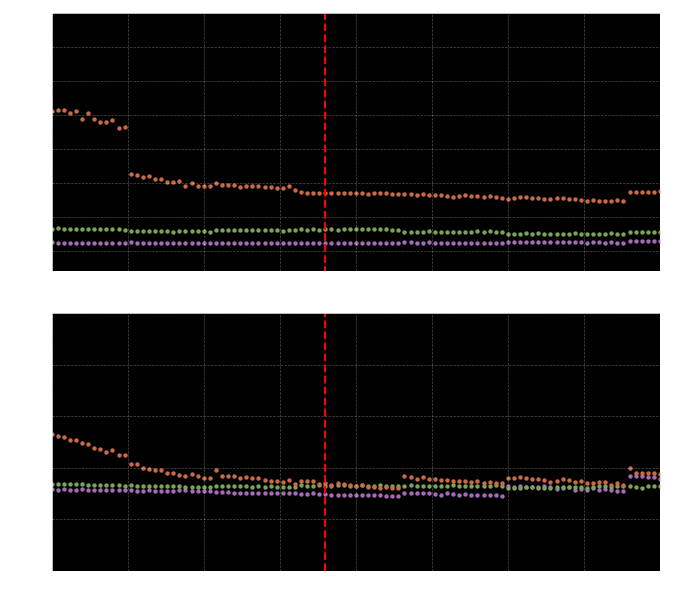

In [11]:
fig, axs = plotter.two_column_plot(nrows=2, heightratio=[1,1])


colours = ["#a46cb7",
"#7aa457",
"#cb6a49"]

for i in np.arange(3):
    axs[0] = plotter.scatter_plot(axs[0], x=pixel_size_space, y=np.squeeze(np.array(Overall_XR[:, i, 0, 0])), facecolor=colours[i], lw=0, s=10)


for i in np.arange(3):
    axs[1] = plotter.scatter_plot(axs[1], x=pixel_size_space, y=np.squeeze(np.array(Overall_XR[:, i, 0, 1])), facecolor=colours[i], lw=0, s=10)

for i in np.arange(2):
    axs[i].vlines(x=69, ymin=0, ymax=500, ls='--', color='red')
    axs[i].set_xlim([pixel_size_space.min(), pixel_size_space.max()])

axs[0].set_ylim([1, 20])
axs[1].set_ylim([0, 0.05])

fig_savefolder = (
    "/home/jbeckwith/Documents/pCloud/Chemistry/Lee/Talks+Posters/Conference Presentations/20260302_DurhamTalks/Research/fig/multicolour_camera/pixel_size/"
)
plt.savefig(os.path.join(fig_savefolder, 'Pixel_Size_StandardUnits_FineGrid.svg'), dpi=600, format='svg')
plt.show()

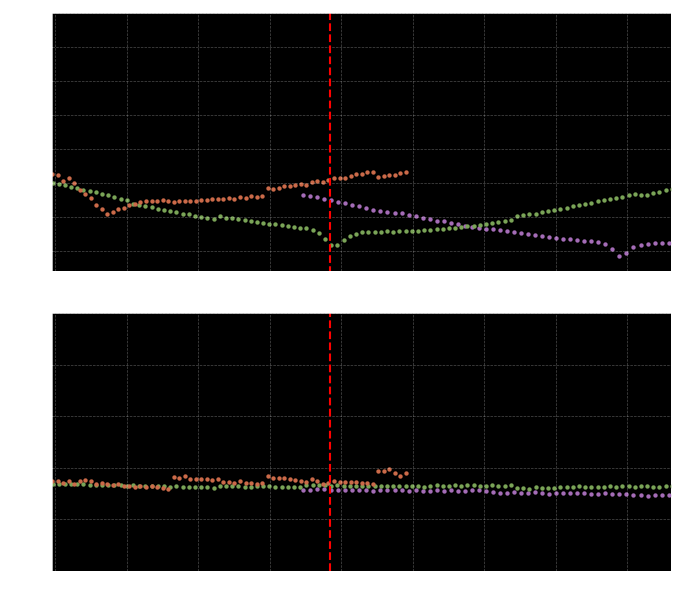

In [30]:
fig, axs = plotter.two_column_plot(nrows=2, heightratio=[1,1])


colours = ["#a46cb7",
"#7aa457",
"#cb6a49"]



for i in np.arange(3):
    axs[0] = plotter.scatter_plot(axs[0], x=pixel_size_space/psf_widths[i], y=np.squeeze(np.array(Overall_XR[:, i, 0, 0])), facecolor=colours[i], lw=0, s=10)


for i in np.arange(3):
    axs[1] = plotter.scatter_plot(axs[1], x=pixel_size_space/psf_widths[i], y=np.squeeze(np.array(Overall_XR[:, i, 0, 1])), facecolor=colours[i], lw=0, s=10)

for i in np.arange(2):
    axs[i].vlines(x=69/np.mean(psf_widths), ymin=0, ymax=500, ls='--', color='red')
    axs[i].set_xlim([pixel_size_space.min()/np.mean(psf_widths), pixel_size_space.max()/np.mean(psf_widths)])

axs[0].set_ylim([1, 20])
axs[1].set_ylim([0, 0.05])

fig_savefolder = (
    "/home/jbeckwith/Documents/pCloud/Chemistry/Lee/Talks+Posters/Conference Presentations/20260302_DurhamTalks/Research/fig/multicolour_camera/pixel_size/"
)
plt.savefig(os.path.join(fig_savefolder, 'Pixel_Size_ReducedUnits_FineGrid.svg'), dpi=600, format='svg')
plt.show()

In [26]:
average_wavelengths, QEs = S_F.get_pixel_fractions_dye_and_filters(dyes, filters=[], wavelength=wavelength, pixel_QYs=pixel_QYs)

In [27]:
psf_widths = PSF.sigma_PSF(average_wavelengths, NA=1.49)

array([ 0.23391023,  1.35135312,  1.41473665])